In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed_German_credit.csv")

sns.set_style("whitegrid")

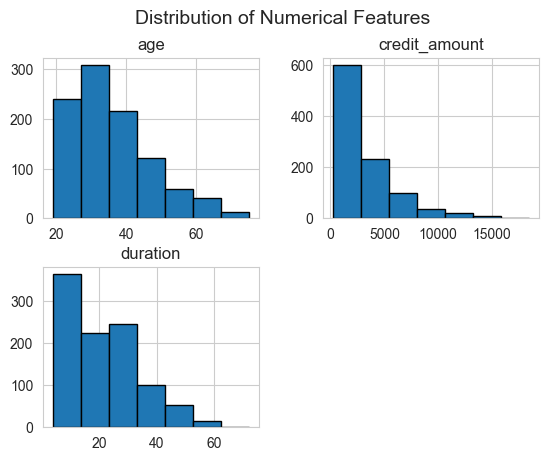

In [2]:
df[["age", "credit_amount", "duration"]].hist(bins=7, edgecolor="black")
plt.suptitle("Distribution of Numerical Features", fontsize=14)
plt.show()

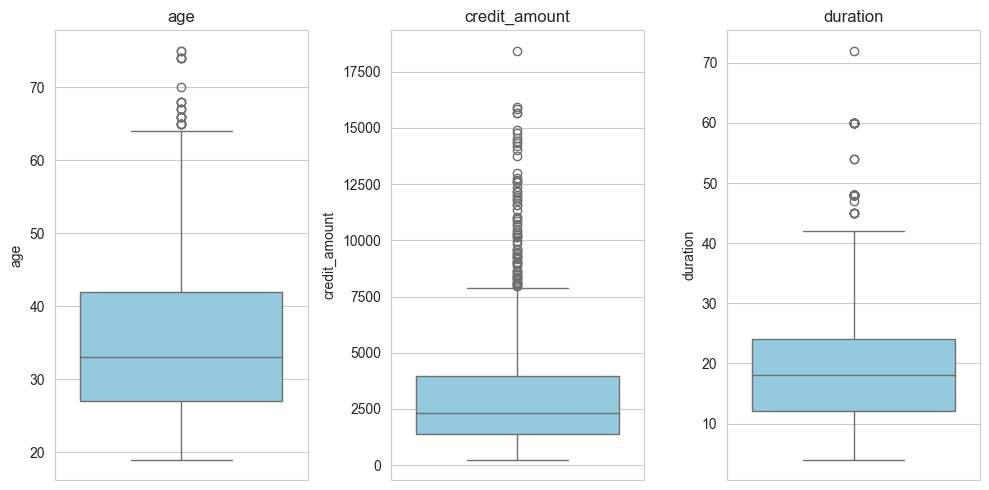

In [3]:
plt.figure(figsize=(10, 5))
for i, col in enumerate(["age", "credit_amount", "duration"]):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(col)
plt.tight_layout()
plt.show()

In [4]:
df.query("duration >=60")

,age,sex,job,housing,saving_account,checking_account,credit_amount,duration,risk,purpose,age_group,credit_per_month,saving_score,checking_score
29,63,male,skilled,own,little,little,6836,60,1,business,Middle-aged,113.933333,1,1
134,21,female,skilled,own,moderate,moderate,10144,60,0,radio/TV,Young,169.066667,2,2
255,27,male,unskilled_and_non-resident,own,little,moderate,7418,60,0,radio/TV,Young,123.633333,1,2
332,24,female,highly skilled,own,moderate,moderate,7408,60,1,car,Young,123.466667,2,2
373,63,male,highly skilled,free,little,moderate,13756,60,0,car,Middle-aged,229.266667,1,2
374,60,female,highly skilled,free,moderate,moderate,14782,60,1,vacation/others,Middle-aged,246.366667,2,2
616,27,male,highly skilled,free,little,moderate,9157,60,0,radio/TV,Young,152.616667,1,2
637,21,male,skilled,own,little,little,15653,60,0,radio/TV,Young,260.883333,1,1
672,42,male,highly skilled,own,little,little,10366,60,0,car,Middle-aged,172.766667,1,1
677,24,male,skilled,own,moderate,moderate,5595,72,1,radio/TV,Young,77.708333,2,2


In [5]:
category_cols=["sex", "job", "housing", "saving_account", "checking_account", "purpose"]

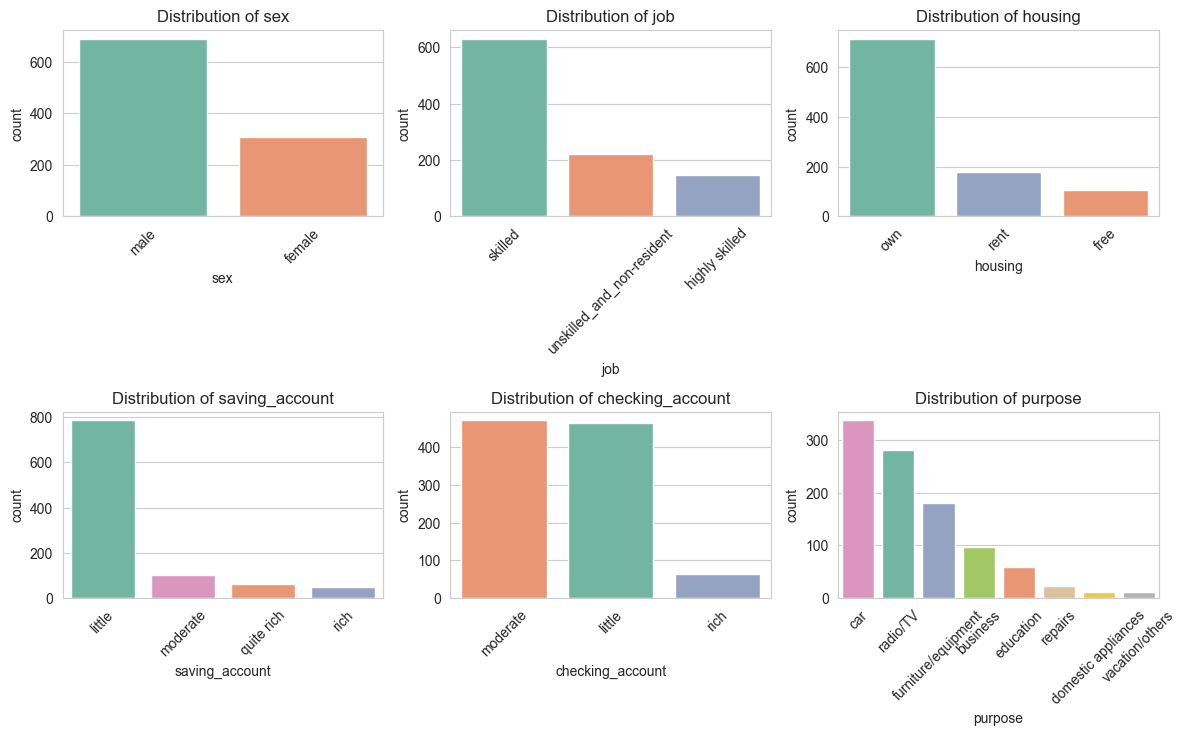

In [6]:
plt.figure(figsize=(12, 10))
for i, col in enumerate(category_cols):
    plt.subplot(3, 3, i + 1)
    sns.countplot(data=df, x=col, hue=col, palette="Set2", order=df[col].value_counts().index, legend=False)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
corr= df[["age", "credit_amount", "duration"]].corr()

In [8]:
corr

,age,credit_amount,duration
age,1.000000,0.032716,-0.036136
credit_amount,0.032716,1.000000,0.624984
duration,-0.036136,0.624984,1.000000


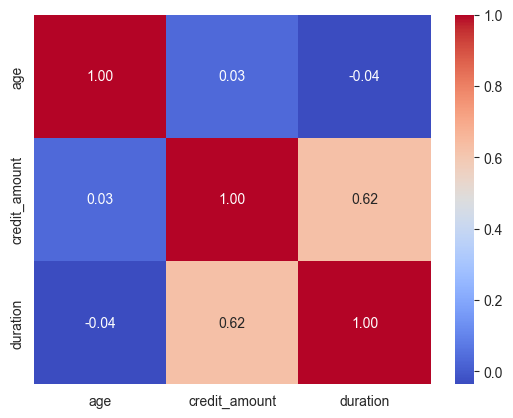

In [9]:
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [10]:
df.groupby("purpose")["credit_amount"].mean()

purpose
business               4158.041237
car                    3768.192878
domestic appliances    1498.000000
education              2879.203390
furniture/equipment    3066.988950
radio/TV               2487.653571
repairs                2728.090909
vacation/others        8209.333333
Name: credit_amount, dtype: float64

In [11]:
df.groupby("sex")["credit_amount"].mean()   

sex
female    2877.774194
male      3448.040580
Name: credit_amount, dtype: float64

In [12]:
pd.pivot_table(df, values="credit_amount", index="housing", columns="purpose")

purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
housing,,,,,,,,
free,4931.800000,5834.181818,NaN,4387.266667,4100.181818,2417.333333,2750.666667,7227.250
own,3800.592105,3329.949772,1546.5,2198.647059,3107.459016,2540.493392,2866.000000,8700.375
rent,5614.125000,3487.968254,1255.5,2931.000000,2727.354167,2199.763158,1522.000000,NaN


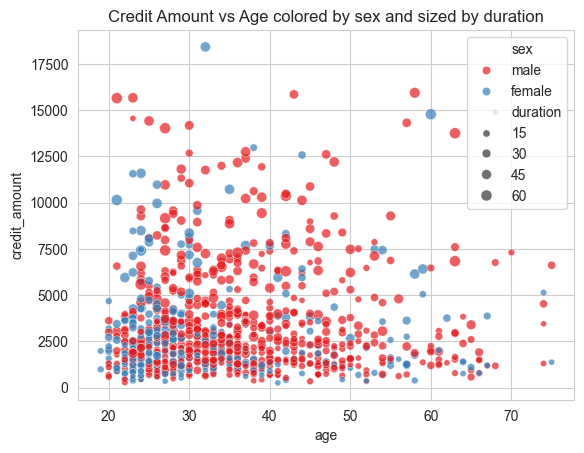

In [13]:
sns.scatterplot(data=df, x="age", y="credit_amount", hue="sex",size= "duration", alpha=0.7, palette="Set1")
plt.title("Credit Amount vs Age colored by sex and sized by duration")
plt.show()

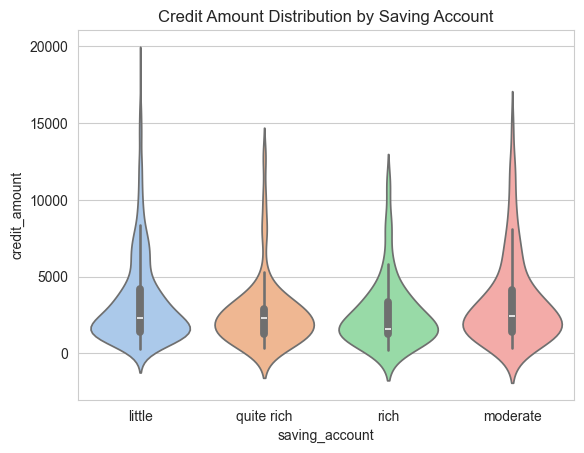

In [14]:
sns.violinplot(data=df, x="saving_account", y="credit_amount", hue="saving_account", palette="pastel", legend=False)
plt.title("Credit Amount Distribution by Saving Account")
plt.show()

In [15]:
df["risk"].value_counts(normalize=True) * 100

risk
0    70.0
1    30.0
Name: proportion, dtype: float64

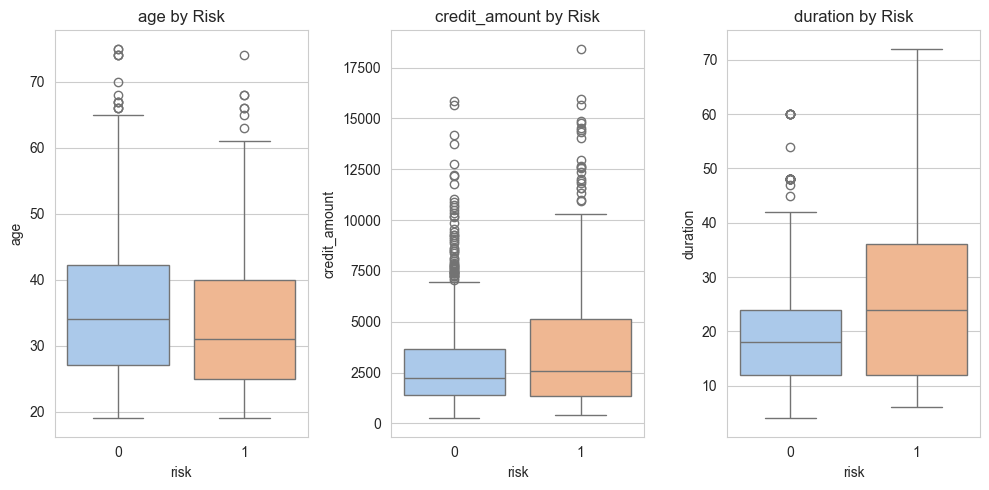

In [16]:
# # plt.figure(figsize=(10, 5))
# for i, col in enumerate(["age", "credit_amount", "duration"]):
#     plt.subplot(1, 3, i + 1)
#     sns.boxplot(x="risk", y=col, data=df, hue="risk", palette="pastel", legend=False)
#     plt.title(f"{col} by Risk")
# plt.tight_layout()
# plt.show()
fig, axes = plt.subplots(1, 3, figsize=(10, 5))
for ax, col in zip(axes, ["age", "credit_amount", "duration"]):
    sns.boxplot(x="risk", y=col, data=df, hue="risk", palette="pastel", legend=False, ax=ax)
    ax.set_title(f"{col} by Risk")
fig.tight_layout()
plt.show()

In [17]:
df.groupby("risk")[["age","credit_amount"]].mean()

,age,credit_amount
risk,,
0,36.224286,2985.457143
1,33.963333,3938.126667


In [18]:
category_cols

['sex', 'job', 'housing', 'saving_account', 'checking_account', 'purpose']

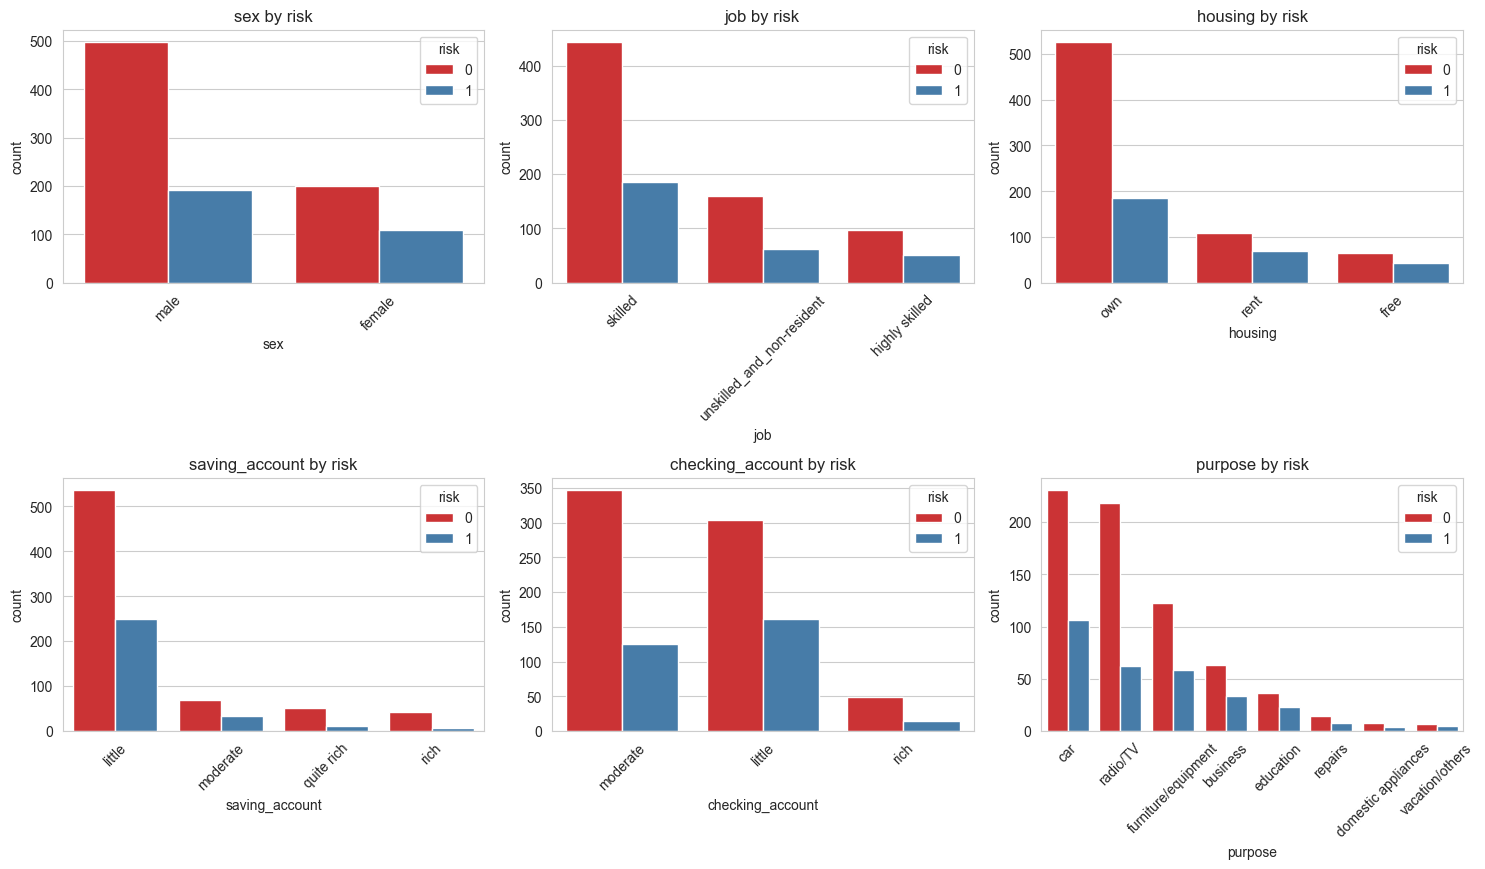

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 12))

for i, col in enumerate(category_cols):
    plt.subplot(len(category_cols)//3 + 1, 3, i + 1)
    sns.countplot(data=df, x=col, hue="risk", palette="Set1",
                  order=df[col].value_counts().index)
    plt.title(f"{col} by risk")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [20]:
df.columns

Index(['age', 'sex', 'job', 'housing', 'saving_account', 'checking_account',
       'credit_amount', 'duration', 'risk', 'purpose', 'age_group',
       'credit_per_month', 'saving_score', 'checking_score'],
      dtype='object')

In [21]:
job_map = {
    'unskilled_and_non-resident': 0,
    'skilled': 1,
    'highly skilled': 2
}
df['job'] = df['job'].map(job_map)

In [22]:
features = ["age", "sex", "job", "housing", "saving_account", "checking_account", "credit_amount", "duration"]

In [23]:
target = "risk"

In [24]:
df_model = df[features + [target]].copy()

In [25]:
df_model.head()

,age,sex,job,housing,saving_account,checking_account,credit_amount,duration,risk
0,67,male,1,own,little,little,1169,6,0
1,22,female,1,own,little,moderate,5951,48,1
2,49,male,0,own,little,little,2096,12,0
3,45,male,1,free,little,little,7882,42,0
4,53,male,1,free,little,little,4870,24,1


In [26]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [27]:
cat_cols= df_model.select_dtypes(include="object").columns

In [28]:
le_dict = {}

In [29]:
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le
    joblib.dump(le, f"{col}_encoder.pkl")

In [30]:
le_target= LabelEncoder()

In [31]:
df_model[target].value_counts()

risk
0    700
1    300
Name: count, dtype: int64

In [32]:
joblib.dump(le_target, f"{target}_encoder.pkl")

['risk_encoder.pkl']

In [33]:
df_model.head()

,age,sex,job,housing,saving_account,checking_account,credit_amount,duration,risk
0,67,1,1,1,0,0,1169,6,0
1,22,0,1,1,0,1,5951,48,1
2,49,1,0,1,0,0,2096,12,0
3,45,1,1,0,0,0,7882,42,0
4,53,1,1,0,0,0,4870,24,1


In [34]:
from sklearn.model_selection import train_test_split

In [35]:
x=df_model.drop(columns=target, axis=1)

In [36]:
y=df_model[target]

In [37]:
x

,age,sex,job,housing,saving_account,checking_account,credit_amount,duration
0,67,1,1,1,0,0,1169,6
1,22,0,1,1,0,1,5951,48
2,49,1,0,1,0,0,2096,12
3,45,1,1,0,0,0,7882,42
4,53,1,1,0,0,0,4870,24
...,...,...,...,...,...,...,...,...
995,31,0,0,1,0,0,1736,12
996,40,1,2,1,0,0,3857,30
997,38,1,1,1,0,0,804,12
998,23,1,1,0,0,0,1845,45


In [38]:
y

0      0
1      1
2      0
3      0
4      1
      ..
995    0
996    0
997    0
998    1
999    0
Name: risk, Length: 1000, dtype: int64

In [39]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y,random_state=1)

In [40]:
x_train.shape

(800, 8)

In [41]:
x_test.shape

(200, 8)

In [42]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier , ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [ ]:
def train_model(model, param_grid, x_train, y_train, x_test, y_test):
    grid = GridSearchCV(model, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
    grid.fit(x_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    return best_model, accuracy, grid.best_params_

In [44]:
dt = DecisionTreeClassifier( random_state= 1, class_weight= "balanced")
dt_param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [52]:
best_dt, accuracy_dt, params_dt= train_model(dt, dt_param_grid, x_train, y_train, x_test, y_test)


NameError: name 'acc' is not defined

In [ ]:
print("Decision Tree Accuracy", acc_dt)

Decision Tree Accuracy 0.645


In [ ]:
print("Best Parameters", params_dt)

Best Parameters {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}


In [ ]:
rf= RandomForestClassifier(random_state=1, class_weight="balanced", n_jobs=-1)

In [ ]:
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [ ]:
best_rf, acc_rf, params_rf= train_model(rf, rf_param_grid, x_train, y_train, x_test, y_test)

In [ ]:
print("Random Forest Accuracy", acc_rf)

Random Forest Accuracy 0.695


In [ ]:
print("Best Parameters", params_rf)

Best Parameters {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [ ]:
et= ExtraTreesClassifier(random_state=1, class_weight="balanced", n_jobs=-1)

In [ ]:
et_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [ ]:
best_et, acc_et, params_et= train_model(et, et_param_grid, x_train, y_train, x_test, y_test)

In [ ]:
print("Extra Trees Accuracy", acc_et)

Extra Trees Accuracy 0.69


In [ ]:
print("Best Params:", params_et)

Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
xgb= XGBClassifier(random_state=1, scale_pos_weight=  (y_train==0).sum() / (y_train==1).sum(), use_label_encoder= False, eval_matric ="logloss")

In [ ]:
xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7,],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.7, 1],
    "colsample_bytree": [0.7, 1]
}

In [ ]:
best_xgb, acc_xgb, params_xgb= train_model(xgb, xgb_param_grid, x_train, y_train, x_test, y_test)   

c:\Users\User\Desktop\Credit_Risk_Analysis\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:21:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "eval_matric", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
print("XGB Accuracy", acc_xgb)

XGB Accuracy 0.605


In [ ]:
print("Best Params", params_xgb)

Best Params {'colsample_bytree': 0.7, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1}
